In [10]:
# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from google.colab import drive

drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/EEG_Project/data/processed/' # Corrected path

# Load Data
print("Loading data from Drive...")
X_train = np.load(f'{data_path}X_train.npy')
y_train = np.load(f'{data_path}y_train.npy')
X_test  = np.load(f'{data_path}X_test.npy')
y_test  = np.load(f'{data_path}y_test.npy')

# Convert to PyTorch Tensors
# Input shape needs to be (Batch, 1, Channels, Time) for Conv2d
tensor_x_train = torch.Tensor(X_train).unsqueeze(1)
tensor_y_train = torch.LongTensor(y_train)
tensor_x_test  = torch.Tensor(X_test).unsqueeze(1)
tensor_y_test  = torch.LongTensor(y_test)

# Create DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(tensor_x_train, tensor_y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(tensor_x_test, tensor_y_test), batch_size=BATCH_SIZE, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data from Drive...
Using device: cuda


In [11]:
import os

# List contents of the data_path to debug the FileNotFoundError
print(f"Listing contents of: {data_path}")
if os.path.exists(data_path):
    for root, dirs, files in os.walk(data_path):
        for file in files:
            print(os.path.join(root, file))
else:
    print("The specified data path does not exist. Please check the path or ensure the data is uploaded.")

Listing contents of: /content/drive/MyDrive/EEG_Project/data/processed/
/content/drive/MyDrive/EEG_Project/data/processed/X_train.npy
/content/drive/MyDrive/EEG_Project/data/processed/y_train.npy
/content/drive/MyDrive/EEG_Project/data/processed/X_test.npy
/content/drive/MyDrive/EEG_Project/data/processed/y_test.npy


Please run the above cell. If the files are not listed, you might need to upload them to the specified Google Drive folder, or provide the correct path where your data is stored. Once the files are accessible, I can proceed with the rest of the notebook.

In [12]:
# ==========================================
# 2. MODEL DEFINITION (CNN + RNN)
# ==========================================
class HybridCNNRNN(nn.Module):
    def __init__(self, num_classes):
        super(HybridCNNRNN, self).__init__()

        # Block 1: Time-Frequency Extraction (CNN)
        # Kernel (1, 64) acts as a Frequency filter over time
        self.conv1 = nn.Conv2d(1, 32, kernel_size=(1, 64), padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.AvgPool2d((1, 4)) # Reduce time dimension

        # Kernel (64, 1) mixes Spatial information (Channels)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(64, 1), padding='valid')
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.AvgPool2d((1, 4)) # Reduce time dimension further

        # Block 2: Temporal Sequence Learning (LSTM)
        self.lstm = nn.LSTM(input_size=64, hidden_size=128, batch_first=True, bidirectional=False)

        # Block 3: Classification
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (Batch, 1, 64, 640)

        # CNN Forward
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))

        # Shape is now: (Batch, 64, 1, Reduced_Time)
        # We need: (Batch, Time, Features) for LSTM
        x = x.permute(0, 3, 1, 2) # (Batch, Reduced_Time, 64, 1)
        x = x.squeeze(-1)         # (Batch, Reduced_Time, 64)

        # LSTM Forward
        # LSTM returns (out, (hn, cn))
        # We use the last hidden state: hn[-1]
        _, (hn, _) = self.lstm(x)
        x = hn[-1]

        # Classification
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Initialize
num_classes = len(np.unique(y_train))
model = HybridCNNRNN(num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()



In [13]:
# ==========================================
# 3. TRAINING LOOP
# ==========================================
def train(epochs=30):
    train_accs, test_accs = [], []

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        train_accs.append(train_acc)

        # Validate
        model.eval()
        correct_v = 0
        total_v = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total_v += labels.size(0)
                correct_v += (predicted == labels).sum().item()

        test_acc = 100 * correct_v / total_v
        test_accs.append(test_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

    return train_accs, test_accs

history = train(epochs=25) # Run training


Epoch 1/25 | Train Acc: 49.42% | Test Acc: 55.50%
Epoch 2/25 | Train Acc: 86.24% | Test Acc: 89.25%
Epoch 3/25 | Train Acc: 96.38% | Test Acc: 92.87%
Epoch 4/25 | Train Acc: 97.21% | Test Acc: 73.58%
Epoch 5/25 | Train Acc: 98.37% | Test Acc: 92.73%
Epoch 6/25 | Train Acc: 91.38% | Test Acc: 85.02%
Epoch 7/25 | Train Acc: 97.07% | Test Acc: 95.74%
Epoch 8/25 | Train Acc: 99.23% | Test Acc: 96.19%
Epoch 9/25 | Train Acc: 99.39% | Test Acc: 98.78%
Epoch 10/25 | Train Acc: 99.94% | Test Acc: 97.73%
Epoch 11/25 | Train Acc: 100.00% | Test Acc: 98.29%
Epoch 12/25 | Train Acc: 99.89% | Test Acc: 98.45%
Epoch 13/25 | Train Acc: 100.00% | Test Acc: 98.29%
Epoch 14/25 | Train Acc: 99.97% | Test Acc: 98.76%
Epoch 15/25 | Train Acc: 100.00% | Test Acc: 98.87%
Epoch 16/25 | Train Acc: 100.00% | Test Acc: 98.51%
Epoch 17/25 | Train Acc: 99.97% | Test Acc: 98.29%
Epoch 18/25 | Train Acc: 99.53% | Test Acc: 92.40%
Epoch 19/25 | Train Acc: 99.81% | Test Acc: 96.46%
Epoch 20/25 | Train Acc: 98.37% | Te


--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       366
           1       0.97      1.00      0.98       360
           2       1.00      0.91      0.95       366
           3       1.00      0.75      0.86       360
           4       1.00      1.00      1.00       360
           5       0.83      1.00      0.91       360
           6       0.99      1.00      1.00       366
           7       0.98      0.96      0.97       360
           8       1.00      1.00      1.00       360
           9       0.89      1.00      0.94       360

    accuracy                           0.96      3618
   macro avg       0.97      0.96      0.96      3618
weighted avg       0.97      0.96      0.96      3618



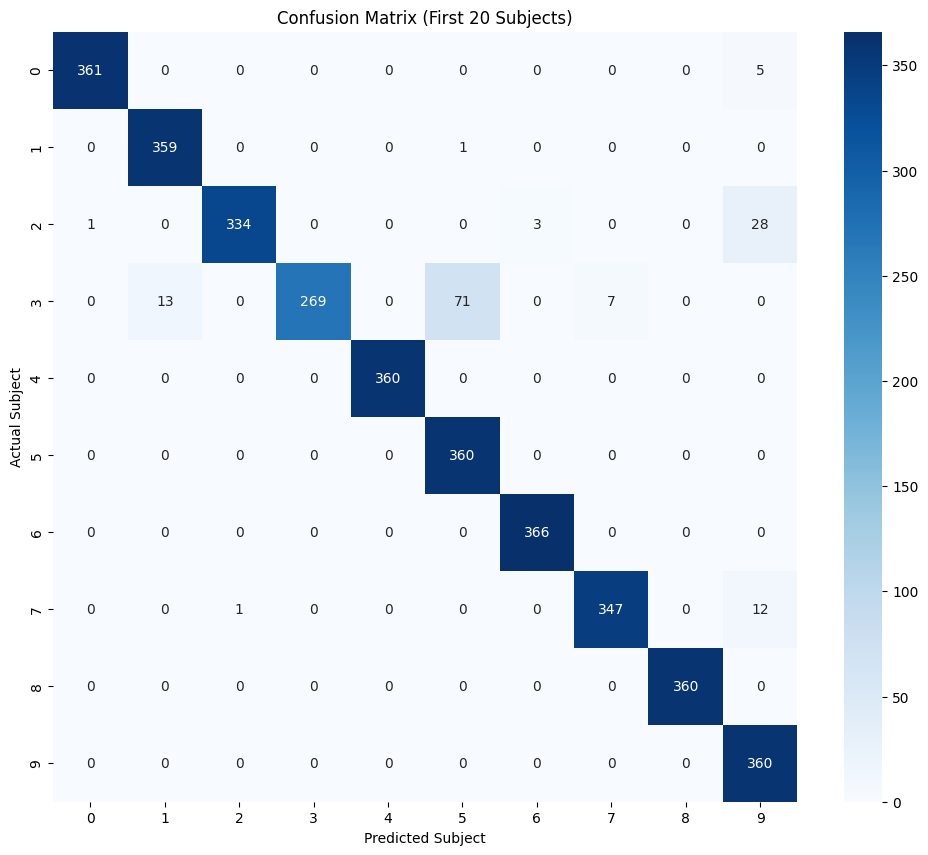

In [14]:
# ==========================================
# 4. PERFORMANCE REPORT
# ==========================================
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# 1. Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred))

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
# Plotting first 20 subjects for clarity (if 109 subjects, full matrix is too big)
sns.heatmap(cm[:20, :20], annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (First 20 Subjects)')
plt.ylabel('Actual Subject')
plt.xlabel('Predicted Subject')
plt.show()
